Скачати файл Most Streamed Spotify Songs 2023 і виконати для нього наступні завдання.
1. Завдання полягає в тому, щоб побудувати горизонтальну стовпчикову діаграму, на якій відображаються 10 найпопулярніших пісень на Spotify у 2023 році за кількістю прослуховувань.

2. Розподіл жанрів найпопулярніших пісень: Створіть кругову діаграму або секторну діаграму, яка відображає розподіл жанрів серед найпопулярніших пісень у 2023 році.

3. Динаміка популярності треку в залежності від часу: Побудуйте лінійний графік, який відображає зміни кількості прослуховувань певного треку протягом року 2023 року.

4. Рейтинг артистів на Spotify: Створіть стовпчикову діаграму, на якій відображаються 10 найпопулярніших артистів на Spotify у 2023 році за кількістю слухачів.

5. Порівняння популярності трьох треків: Побудуйте горизонтальну стовпчикову діаграму, яка порівнює кількість прослуховувань трьох конкретних треків у 2023 році.

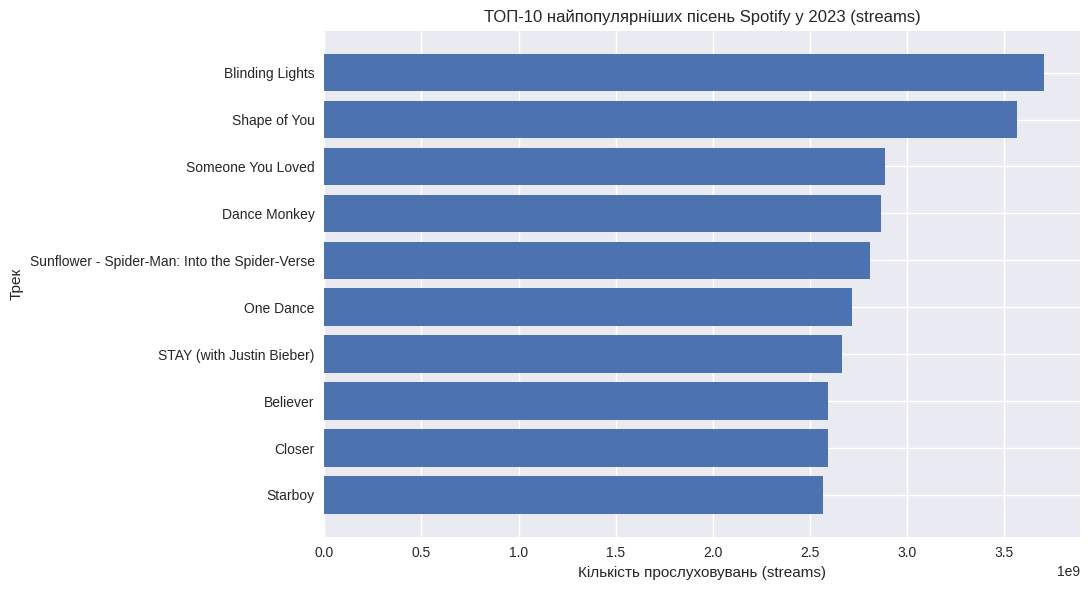

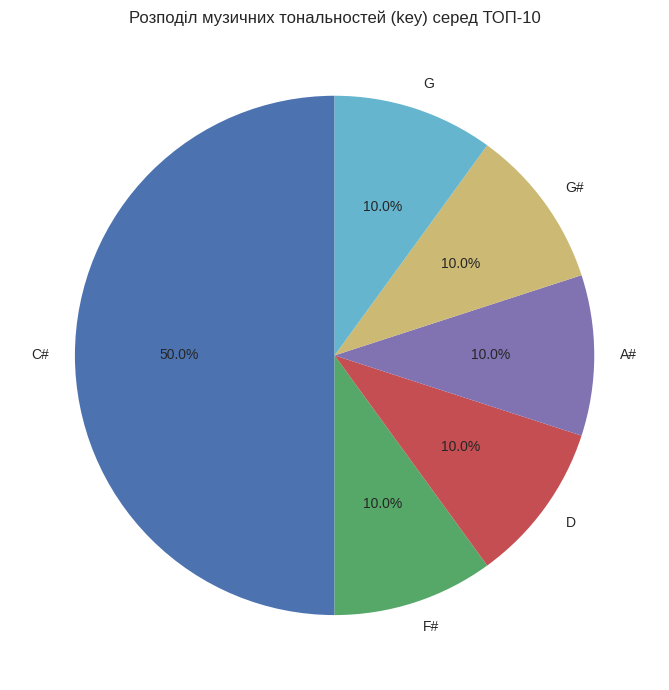

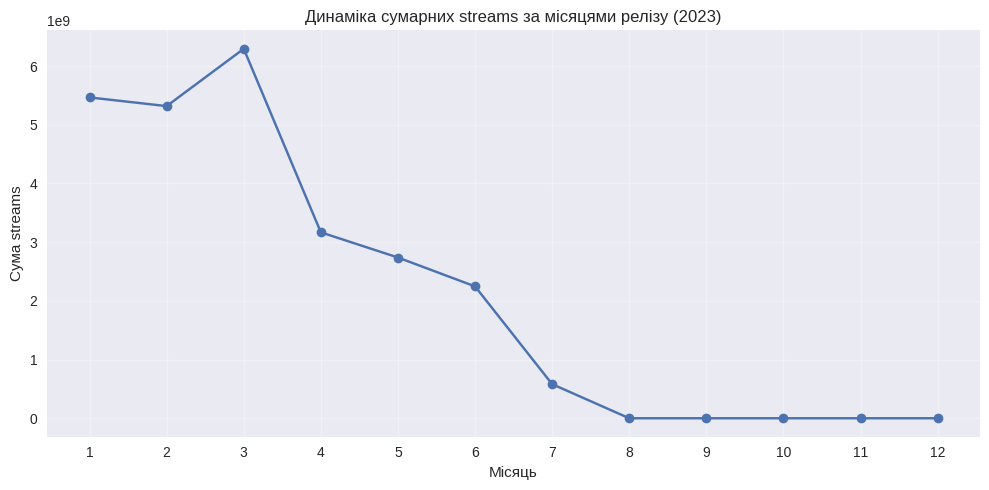

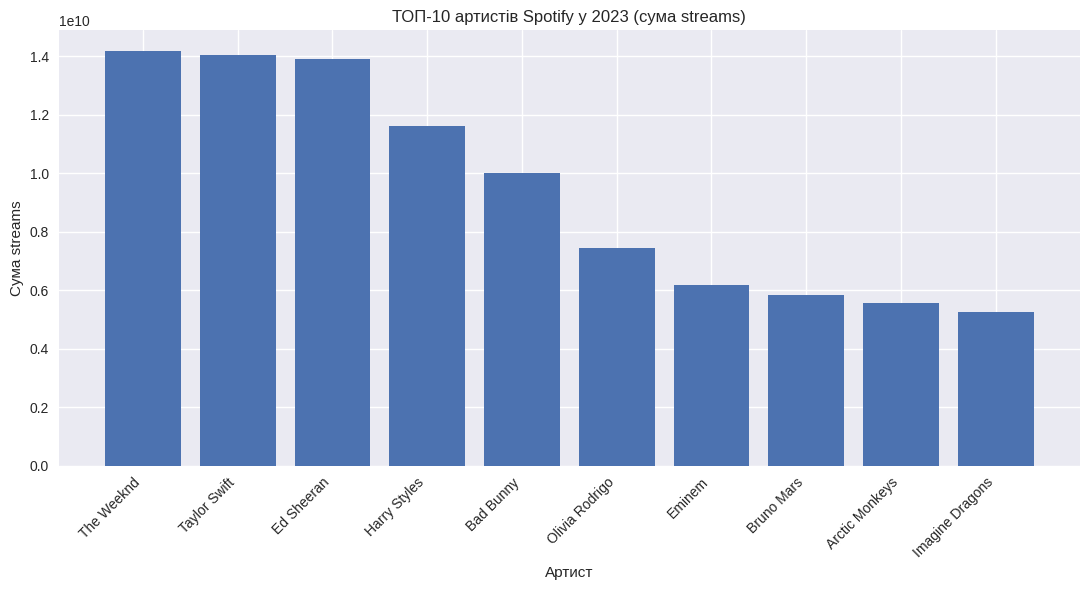

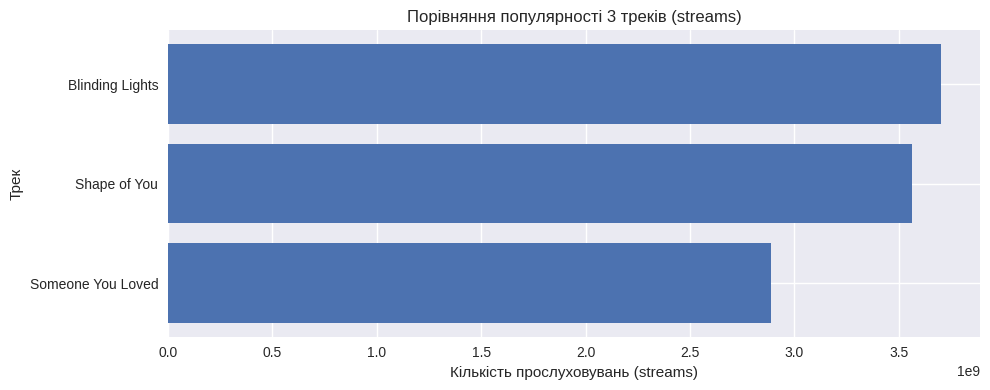

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PATH = "/content/spotify-2023.csv"
try:
    df = pd.read_csv(PATH)
except UnicodeDecodeError:
    df = pd.read_csv(PATH, encoding="latin-1")

df["streams"] = pd.to_numeric(df["streams"].astype(str).str.replace(",", "", regex=False), errors="coerce")
plt.style.use("seaborn-v0_8")

# 1) 10 найпопулярніших пісень за кількістю прослуховувань (горизонтальна стовпчикова діаграма)
top10_tracks = df.dropna(subset=["streams"]).sort_values("streams", ascending=False).head(10)

plt.figure(figsize=(11, 6))
plt.barh(top10_tracks["track_name"], top10_tracks["streams"])
plt.gca().invert_yaxis()
plt.title("ТОП-10 найпопулярніших пісень Spotify у 2023 (streams)")
plt.xlabel("Кількість прослуховувань (streams)")
plt.ylabel("Трек")
plt.tight_layout()
plt.show()

# 2) Розподіл жанрів найпопулярніших пісень (якщо genre нема — використовуємо 'key' як музичну характеристику)
if "genre" in df.columns:
    dist = top10_tracks["genre"].fillna("Unknown").value_counts()
    labels = dist.index
    values = dist.values
    title = "Розподіл жанрів серед ТОП-10"
else:
    dist = top10_tracks["key"].fillna("Unknown").value_counts()
    labels = dist.index
    values = dist.values
    title = "Розподіл музичних тональностей (key) серед ТОП-10"

plt.figure(figsize=(7, 7))
plt.pie(values, labels=labels, autopct="%1.1f%%", startangle=90)
plt.title(title)
plt.tight_layout()
plt.show()

# 3) Динаміка популярності треку протягом 2023 (імітація по місяцях через дату релізу)
df_2023 = df[df["released_year"] == 2023]

monthly_streams = df_2023.groupby("released_month")["streams"].sum().reindex(range(1, 13), fill_value=0)

plt.figure(figsize=(10,5))
plt.plot(monthly_streams.index, monthly_streams.values, marker="o")
plt.title("Динаміка сумарних streams за місяцями релізу (2023)")
plt.xlabel("Місяць")
plt.ylabel("Сума streams")
plt.xticks(range(1,13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 4) 10 найпопулярніших артистів за сумарними streams (стовпчикова діаграма)
top10_artists = df.dropna(subset=["streams"]).groupby("artist(s)_name")["streams"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(11, 6))
plt.bar(top10_artists.index, top10_artists.values)
plt.title("ТОП-10 артистів Spotify у 2023 (сума streams)")
plt.xlabel("Артист")
plt.ylabel("Сума streams")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 5) Порівняння популярності трьох треків (горизонтальна стовпчикова діаграма)
top3 = df.dropna(subset=["streams"]).sort_values("streams", ascending=False).head(3)

plt.figure(figsize=(10, 4))
plt.barh(top3["track_name"], top3["streams"])
plt.gca().invert_yaxis()
plt.title("Порівняння популярності 3 треків (streams)")
plt.xlabel("Кількість прослуховувань (streams)")
plt.ylabel("Трек")
plt.tight_layout()
plt.show()